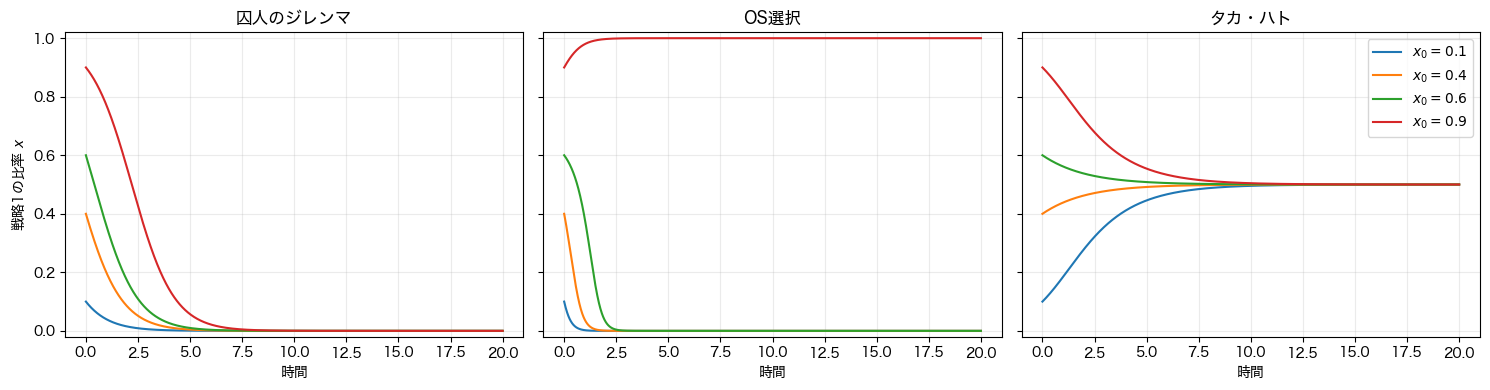

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager

# 利用可能な日本語フォントを選ぶ
preferred_fonts = [
    "Hiragino Sans",
    "Yu Gothic",
    "Noto Sans CJK JP",
    "IPAexGothic",
]
available_fonts = {font.name for font in font_manager.fontManager.ttflist}

for font_name in preferred_fonts:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break

plt.rcParams["axes.unicode_minus"] = False


def replicator_rhs(x, payoff_matrix):
    """2戦略ゲームにおける戦略1の比率の変化率を返す．"""
    a, b = payoff_matrix[0]
    c, d = payoff_matrix[1]

    fitness_1 = a * x + b * (1 - x)
    fitness_2 = c * x + d * (1 - x)

    return x * (1 - x) * (fitness_1 - fitness_2)


def simulate(payoff_matrix, initial_x, dt=0.01, periods=20):
    """オイラー法でレプリケータダイナミクスを近似する．"""
    steps = int(periods / dt)
    path = np.empty(steps + 1)
    path[0] = initial_x

    for step in range(steps):
        x = path[step]
        next_x = x + dt * replicator_rhs(x, payoff_matrix)
        path[step + 1] = np.clip(next_x, 0, 1)

    time = np.linspace(0, periods, steps + 1)
    return time, path


games = {
    "囚人のジレンマ": np.array([[2, -1], [3, 0]], dtype=float),
    "OS選択": np.array([[2, 0], [0, 4]], dtype=float),
    "タカ・ハト": np.array([[2, 1], [3, 0]], dtype=float),
}

initial_states = [0.1, 0.4, 0.6, 0.9]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (game_name, payoff_matrix) in zip(axes, games.items()):
    for initial_x in initial_states:
        time, path = simulate(payoff_matrix, initial_x)
        ax.plot(time, path, label=f"$x_0={initial_x}$")

    ax.set_title(game_name)
    ax.set_xlabel("時間")
    ax.set_ylim(-0.02, 1.02)
    ax.grid(alpha=0.25)

axes[0].set_ylabel("戦略1の比率 $x$")
axes[-1].legend(loc="best")

plt.tight_layout()
plt.show()